In [33]:
import tensorflow as tf
from keras.applications.resnet50 import ResNet50
import matplotlib.pyplot as plt
import numpy as np
from tf_explain.core.occlusion_sensitivity import OcclusionSensitivity

In [34]:
model = ResNet50(weights="imagenet") # Vortrainiertes ResNet50-Modell laden

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
Predicitons:  [('n02111889', 'Samoyed', np.float32(0.9477502)), ('n02114548', 'white_wolf', np.float32(0.022208108)), ('n02111500', 'Great_Pyrenees', np.float32(0.009895209))]
class index:  258
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 570ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

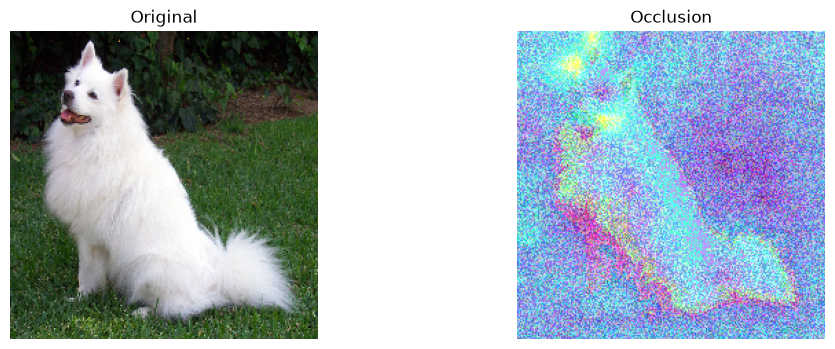

In [35]:
img_path = tf.keras.utils.get_file("dog.jpg", "https://github.com/pytorch/hub/raw/master/images/dog.jpg")
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))

img_array = tf.keras.utils.img_to_array(img)
x = np.expand_dims(img_array.copy(), axis=0)
x = tf.keras.applications.resnet50.preprocess_input(x)

pred = model.predict(x)
class_index = np.argmax(pred[0])

print('Predicitons: ', tf.keras.applications.resnet50.decode_predictions(pred, top=3)[0])
print('class index: ', class_index) # ImageNet Class Index 258=Samoyed https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/
data = (x,None)

occlusion = OcclusionSensitivity().explain(data, model, class_index, patch_size=10) # Schrittweite = patch_size in diesem Fall

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_array.astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(occlusion)
plt.title("Occlusion")
plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
tf.Tensor([258], shape=(1,), dtype=int64)
tf.Tensor(0.9477502, shape=(), dtype=float32)


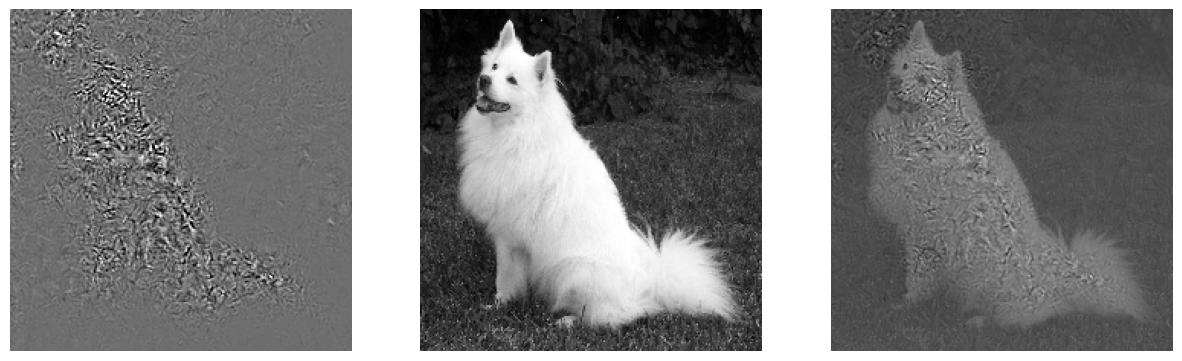

In [36]:
# https://github.com/vectorgrp/coderskitchen-xai/blob/main/part2_TF_guided_backprop.ipynb

img_path = tf.keras.utils.get_file("dog.jpg", "https://github.com/pytorch/hub/raw/master/images/dog.jpg")
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))

img_array = tf.keras.utils.img_to_array(img)
x = np.expand_dims(img_array.copy(), axis=0)
x = tf.keras.applications.resnet50.preprocess_input(x)

pred = model.predict(x)

max_idx = tf.argmax(pred,axis = 1) # Vorhergesagte Klasse
x = tf.cast(x, tf.float32) # Beispielbild

print(max_idx)

with tf.GradientTape() as tape:
    tape.watch(x) # Gradientenberechnung für das Eingabebild aktivieren
    result = model(x)
    max_score = result[0,max_idx[0]]
grads = tape.gradient(max_score, x) # Berechnung der Gradienten des Scores der vorhergesagten Klasse bezüglich des Eingabebildes

print(max_score)

def norm_flat_image(img):
    grads_norm = img[:,:,0]+ img[:,:,1]+ img[:,:,2] # Summieren über alle 3 Farbkanäle
    grads_norm = (grads_norm - tf.reduce_min(grads_norm))/ (tf.reduce_max(grads_norm)- tf.reduce_min(grads_norm))
    return grads_norm

# Aufgrund der Normalisierung entspricht ein graues Pixel einem Gradienten von 0, weiß entspricht einem hohen positiven Gradienten von 1 und schwarz einem hohem negativen Gradienten.

def plot_maps(img1, img2,vmin=0.3,vmax=0.7, mix_val=2):
    f = plt.figure(figsize=(15,45))
    plt.subplot(1,3,1)
    plt.imshow(img1,vmin=vmin, vmax=vmax, cmap="gray")
    plt.axis("off")
    plt.subplot(1,3,2)
    plt.imshow(img2, cmap = "gray")
    plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(img1*mix_val+img2/mix_val, cmap = "gray" )
    plt.axis("off")
plot_maps(norm_flat_image(grads[0]), norm_flat_image(x[0]))

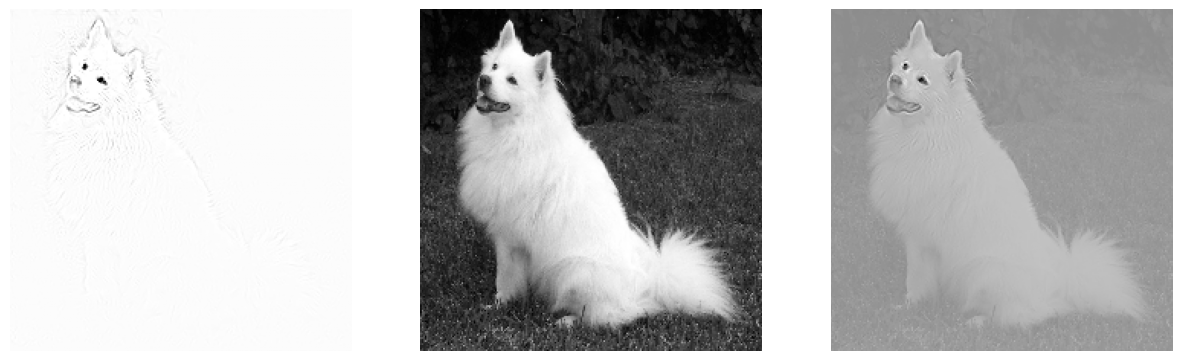

In [37]:
@tf.custom_gradient
def guidedRelu(x):
    def grad(dy):
        return tf.cast(dy>0,tf.float32)  * tf.cast(x>0,tf.float32) * dy # x ist der Input einer ReLU Funktion, y der Output, x und dy müssen >0 sein
                                                                        # der normalerweise verwendete Gradient wird überschrieben
    return tf.nn.relu(x), grad

layer_dict = [layer for layer in model.layers[1:] if hasattr(layer,'activation')] #  Iterier über die Layer des Modells, ohne die erste Schicht
for layer in layer_dict:
    if layer.activation == tf.keras.activations.relu: # Nur ReLU Activation Layer sind relevant
        layer.activation = guidedRelu # für die Activation Layer wird die ReLU Funktion durch die Guided ReLU Funktion ersetzt
        #print("changed")

with tf.GradientTape() as tape:
    tape.watch(x)
    result = model(x)
    max_score = result[0,max_idx[0]]
grads = tape.gradient(max_score, x)

plot_maps(norm_flat_image(grads[0]), norm_flat_image(x[0]))